# Data Consolidation — MIMIC-IV-Ext

**Output:** `Data Preparation/consolidated_dataset_PMH_v2.csv`  
**Schema:** 22 columns × 9,149 rows  

## Section 1 — Imports & Paths

In [9]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

# BASE_PATH points to the Dataset/ directory relative to this notebook.
# This notebook lives in: <project_root>/Data Preparation/
# Dataset/ is at:         <project_root>/Dataset/
BASE_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "Dataset")
BASE_PATH = os.path.normpath(BASE_PATH)

print(f"BASE_PATH resolved to: {BASE_PATH}")
print(f"Files found: {os.listdir(BASE_PATH)}")

BASE_PATH resolved to: /Users/hassanali/Library/Mobile Documents/com~apple~CloudDocs/Capstone Project/Capstone_personal/Dataset
Files found: ['.DS_Store', 'consolidated_dataset_PMH.csv', 'patient_demographics.csv', 'specialty_referral.csv', 'triage_level.csv', 'Speciality_merge.csv', 'specialty_referral_clinician_approved.csv', 'clinical_data.csv', 'README.txt', 'LICENSE.txt', 'diagnosis.csv', 'initial_assessment_info.csv', 'vital_signs.csv']


## Section 2 — Load All Source Files
 
**Important:** These files contain multi-line quoted text fields. Never pass `quoting=` or `lineterminator=` — pandas default quoting (QUOTE_MINIMAL) handles them correctly.

In [10]:
# --- clinical_data.csv ---
# Contains: stay_id, text (full clinical note), HPI, tests, past_medication,
#           diagnosis, primary_diagnosis, secondary_diagnosis
df_clinical = pd.read_csv(os.path.join(BASE_PATH, "clinical_data.csv"))
print("=== clinical_data.csv ===")
print(f"Shape: {df_clinical.shape}")
print(df_clinical.dtypes)
print()

# --- vital_signs.csv ---
# Contains: stay_id, subject_id, hadm_id, initial_vitals (text string)
# This is the anchor table — all 9,149 rows with subject_id and hadm_id
df_vitals = pd.read_csv(os.path.join(BASE_PATH, "vital_signs.csv"))
print("=== vital_signs.csv ===")
print(f"Shape: {df_vitals.shape}")
print(df_vitals.dtypes)
print()

# --- patient_demographics.csv ---
# Contains: stay_id, patient_info (text string with gender, race, age)
df_demo = pd.read_csv(os.path.join(BASE_PATH, "patient_demographics.csv"))
print("=== patient_demographics.csv ===")
print(f"Shape: {df_demo.shape}")
print(df_demo.dtypes)
print()

# --- initial_assessment_info.csv ---
# Contains: stay_id, triage, pain, chiefcomplaint, arrival_transport,
#           disposition, icd_code, icd_title, icd_version
df_assess = pd.read_csv(os.path.join(BASE_PATH, "initial_assessment_info.csv"))
print("=== initial_assessment_info.csv ===")
print(f"Shape: {df_assess.shape}")
print(df_assess.dtypes)
print()

# --- specialty_referral.csv ---
# Contains: stay_id + specialty column; only 2,200 rows.
# The remaining ~6,949 rows will have NaN for specialty after the left join.
df_specialty = pd.read_csv(os.path.join(BASE_PATH, "specialty_referral.csv"))
print("=== specialty_referral.csv ===")
print(f"Shape: {df_specialty.shape}")
print(df_specialty.dtypes)

=== clinical_data.csv ===
Shape: (9149, 8)
stay_id                 int64
text                   object
HPI                    object
tests                  object
past_medication        object
diagnosis              object
primary_diagnosis      object
secondary_diagnosis    object
dtype: object

=== vital_signs.csv ===
Shape: (9149, 4)
stay_id            int64
subject_id         int64
hadm_id            int64
initial_vitals    object
dtype: object

=== patient_demographics.csv ===
Shape: (9149, 2)
stay_id          int64
patient_info    object
dtype: object

=== initial_assessment_info.csv ===
Shape: (9149, 9)
stay_id               int64
triage                int64
pain                 object
chiefcomplaint       object
arrival_transport    object
disposition          object
icd_code             object
icd_title            object
icd_version           int64
dtype: object

=== specialty_referral.csv ===
Shape: (2200, 5)
stay_id            int64
HPI               object
patient_info     

## Section 3 — Enhanced EDA

Deep-dive analysis per column type: parsed distributions, class imbalances, text length profiles, cross-variable relationships, and outlier detection. Charts are inline. Source dataframes (`df_vitals`, `df_clinical`, `df_demo`, `df_assess`, `df_specialty`) must be loaded before running these cells.

In [11]:
# ── 3.1  initial_vitals — parse structured values from text strings ──────────
import re

VITAL_PATTERNS = {
    "Temperature":   r"Temperature:\s*([\d.]+)",
    "Heart Rate":    r"Heartrate:\s*([\d.]+)",
    "Resp Rate":     r"resprate:\s*([\d.]+)",
    "O2 Sat (%)":   r"o2sat:\s*([\d.]+)",
    "SBP":          r"sbp:\s*([\d.]+)",
    "DBP":          r"dbp:\s*([\d.]+)",
}

def parse_vitals(text):
    row = {}
    for name, pattern in VITAL_PATTERNS.items():
        m = re.search(pattern, str(text), re.IGNORECASE)
        row[name] = float(m.group(1)) if m else None
    return row

df_vitals_parsed = df_vitals["initial_vitals"].apply(parse_vitals).apply(pd.Series)
df_vitals_parsed.insert(0, "stay_id", df_vitals["stay_id"])

print("Parsed vitals shape:", df_vitals_parsed.shape)
print("\nNull counts per vital field:")
print(df_vitals_parsed.drop(columns="stay_id").isna().sum().to_string())
print("\nDescriptive stats:")
print(df_vitals_parsed.drop(columns="stay_id").describe().round(2))

Parsed vitals shape: (9149, 7)

Null counts per vital field:
Temperature    581
Heart Rate     397
Resp Rate      513
O2 Sat (%)     484
SBP            408
DBP            425

Descriptive stats:
       Temperature  Heart Rate  Resp Rate  O2 Sat (%)       SBP      DBP
count      8568.00     8752.00    8636.00     8665.00   8741.00  8724.00
mean         98.11       85.41      17.55       98.05    136.65    78.04
std           2.46       18.13       2.37        3.05    211.06    98.69
min           6.80        9.00       6.00        9.00     10.00     4.00
25%          97.60       73.00      16.00       97.00    119.00    66.00
50%          98.10       84.00      18.00       99.00    133.00    76.00
75%          98.60       96.00      18.00      100.00    148.00    86.00
max         106.60      190.00      48.00      100.00  19734.00  6698.00


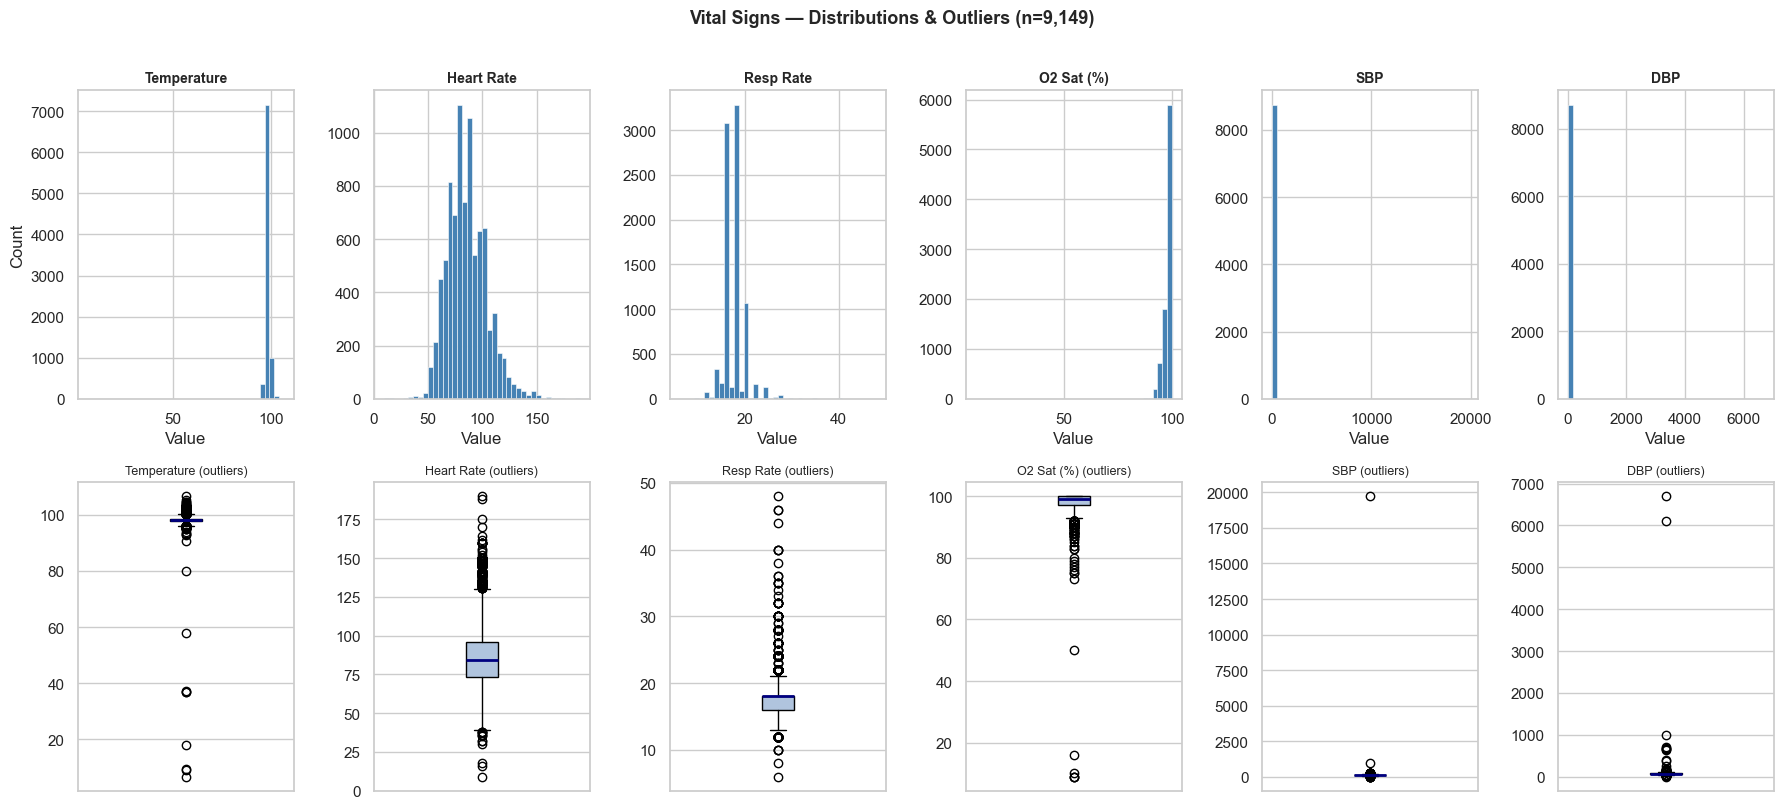

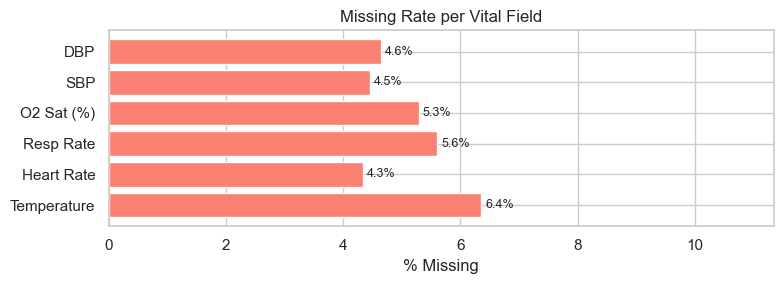

In [12]:
# ── 3.2  Vital Signs — histograms and boxplots ───────────────────────────────
vital_cols = list(VITAL_PATTERNS.keys())
fig, axes = plt.subplots(2, len(vital_cols), figsize=(18, 8))

for i, col in enumerate(vital_cols):
    data = df_vitals_parsed[col].dropna()
    # Histogram
    axes[0, i].hist(data, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
    axes[0, i].set_title(col, fontsize=10, fontweight="bold")
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Count" if i == 0 else "")
    # Boxplot
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor="lightsteelblue"),
                       medianprops=dict(color="navy", linewidth=2))
    axes[1, i].set_title(f"{col} (outliers)", fontsize=9)
    axes[1, i].set_xticks([])

fig.suptitle("Vital Signs — Distributions & Outliers (n=9,149)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Missing rate per vital
missing_pct = df_vitals_parsed[vital_cols].isna().mean() * 100
fig2, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(vital_cols, missing_pct, color="salmon")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_xlabel("% Missing")
ax.set_title("Missing Rate per Vital Field")
ax.set_xlim(0, max(missing_pct.max() + 5, 5))
plt.tight_layout()
plt.show()

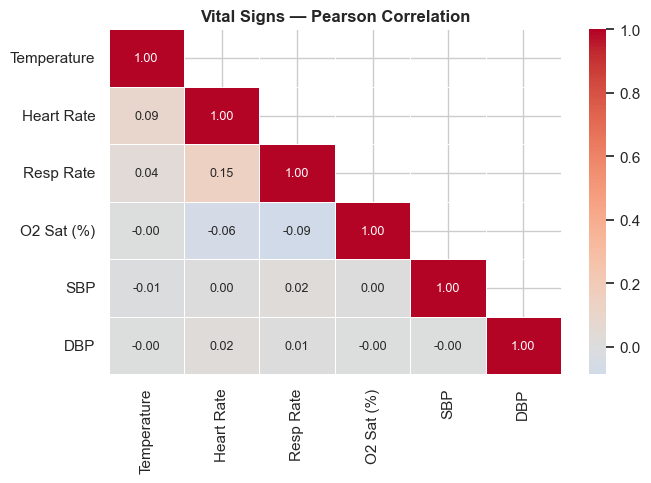

In [13]:
# ── 3.3  Vital Signs — correlation heatmap ───────────────────────────────────
import numpy as np

corr = df_vitals_parsed[vital_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
# Mask upper triangle to avoid redundancy
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask_upper, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Vital Signs — Pearson Correlation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

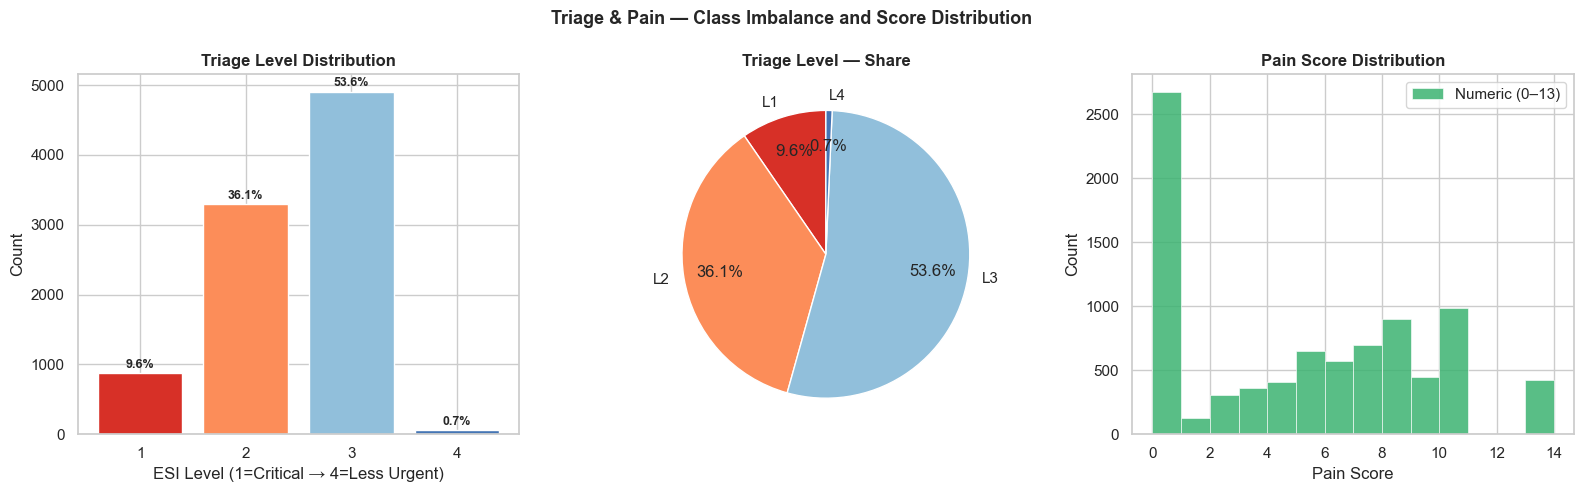

Non-numeric pain values (string-encoded):
pain
unable                 79
Critical               47
uta                    35
ua                     23
UTA                    21
critical                8
c                       7
UA                      6
unable                  5
prehosp                 5
o                       3
yes                     3
Unable                  3
5-6                     3
4-5                     3
6-7                     3
u/a                     3
8-9                     3
mild                    2
u                       2
2-3                     2
?                       2
alot                    2
Non-verbal              2
controlled              2
ett                     2
not too bad             2
pain                    2
crit                    2
+                       2
asleep                  1
Refusing                1
7-8                     1
Yes                     1
3-4                     1
uta                     1
crit             

In [14]:
# ── 3.4  Triage level + Pain score distributions ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Triage bar chart ---
triage_counts = df_assess["triage"].value_counts().sort_index()
triage_pct    = triage_counts / triage_counts.sum() * 100
bars = axes[0].bar(triage_counts.index.astype(str), triage_counts.values, color=["#d73027","#fc8d59","#91bfdb","#4575b4"])
for bar, pct in zip(bars, triage_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Triage Level Distribution", fontweight="bold")
axes[0].set_xlabel("ESI Level (1=Critical → 4=Less Urgent)")
axes[0].set_ylabel("Count")

# --- Triage pie chart ---
axes[1].pie(triage_counts, labels=[f"L{l}" for l in triage_counts.index],
            autopct="%1.1f%%", colors=["#d73027","#fc8d59","#91bfdb","#4575b4"],
            startangle=90, pctdistance=0.75)
axes[1].set_title("Triage Level — Share", fontweight="bold")

# --- Pain: split numeric vs string-encoded ---
pain_raw = df_assess["pain"].copy()
pain_numeric = pd.to_numeric(pain_raw, errors="coerce")
pain_str_mask = pain_numeric.isna() & pain_raw.notna()

axes[2].hist(pain_numeric.dropna(), bins=range(0, 15), color="mediumseagreen",
             edgecolor="white", linewidth=0.5, alpha=0.85, label="Numeric (0–13)")
axes[2].set_title("Pain Score Distribution", fontweight="bold")
axes[2].set_xlabel("Pain Score")
axes[2].set_ylabel("Count")
axes[2].legend()

fig.suptitle("Triage & Pain — Class Imbalance and Score Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print non-numeric pain values
print("Non-numeric pain values (string-encoded):")
print(pain_raw[pain_str_mask].value_counts(dropna=False).to_string())
print(f"\nTotal non-numeric pain entries: {pain_str_mask.sum()}")
print(f"Total pain nulls: {pain_numeric.isna().sum()} (includes string-encoded)")

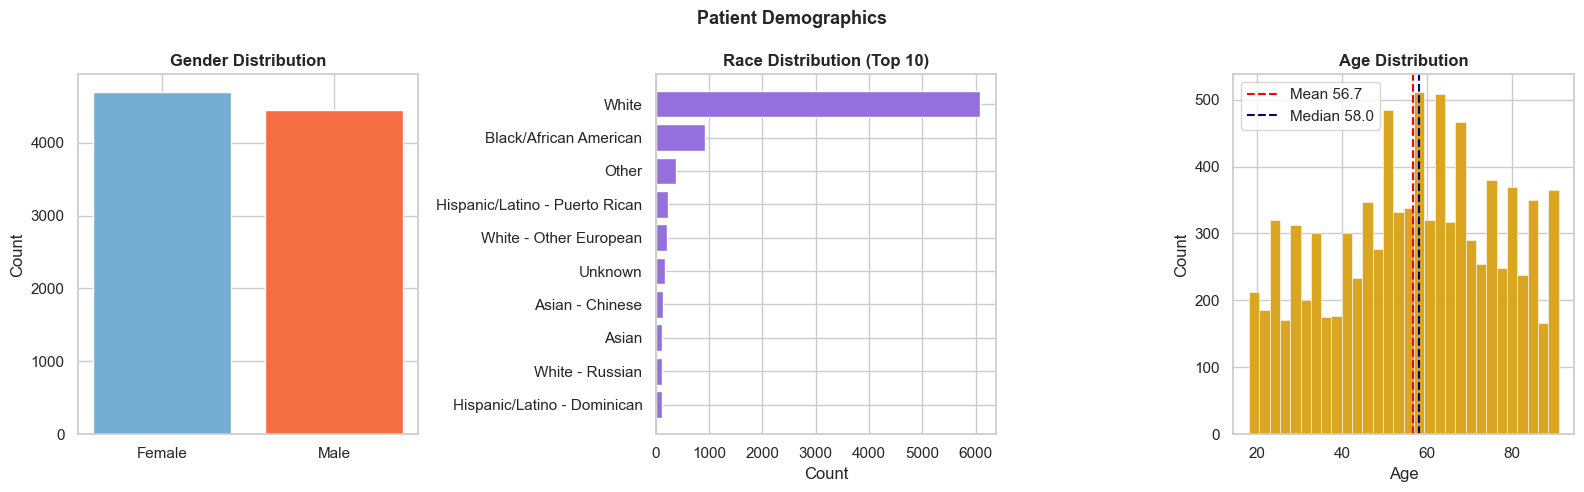

Age stats — min: 18, max: 91, mean: 56.7, std: 19.7


In [15]:
# ── 3.5  patient_info — parse Gender, Race, Age ──────────────────────────────
def parse_demographics(text):
    if not isinstance(text, str):
        return {"Gender": None, "Race": None, "Age": None}
    gender = re.search(r"Gender:\s*(\w+)", text, re.IGNORECASE)
    race   = re.search(r"Race:\s*([^,\n]+)", text, re.IGNORECASE)
    age    = re.search(r"Age:\s*(\d+)", text, re.IGNORECASE)
    return {
        "Gender": gender.group(1).strip().title() if gender else None,
        "Race":   race.group(1).strip().title() if race else None,
        "Age":    int(age.group(1)) if age else None,
    }

df_demo_parsed = df_demo["patient_info"].apply(parse_demographics).apply(pd.Series)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender
gender_counts = df_demo_parsed["Gender"].value_counts(dropna=False)
axes[0].bar(gender_counts.index.astype(str), gender_counts.values, color=["#74add1","#f46d43","#abdda4"])
axes[0].set_title("Gender Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

# Race (top 10)
race_counts = df_demo_parsed["Race"].value_counts(dropna=False).head(10)
axes[1].barh(race_counts.index.astype(str)[::-1], race_counts.values[::-1], color="mediumpurple")
axes[1].set_title("Race Distribution (Top 10)", fontweight="bold")
axes[1].set_xlabel("Count")

# Age histogram
ages = df_demo_parsed["Age"].dropna()
axes[2].hist(ages, bins=30, color="goldenrod", edgecolor="white", linewidth=0.4)
axes[2].axvline(ages.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean {ages.mean():.1f}")
axes[2].axvline(ages.median(), color="navy", linestyle="--", linewidth=1.5, label=f"Median {ages.median():.1f}")
axes[2].set_title("Age Distribution", fontweight="bold")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")
axes[2].legend()

fig.suptitle("Patient Demographics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Age stats — min: {ages.min()}, max: {ages.max()}, mean: {ages.mean():.1f}, std: {ages.std():.1f}")

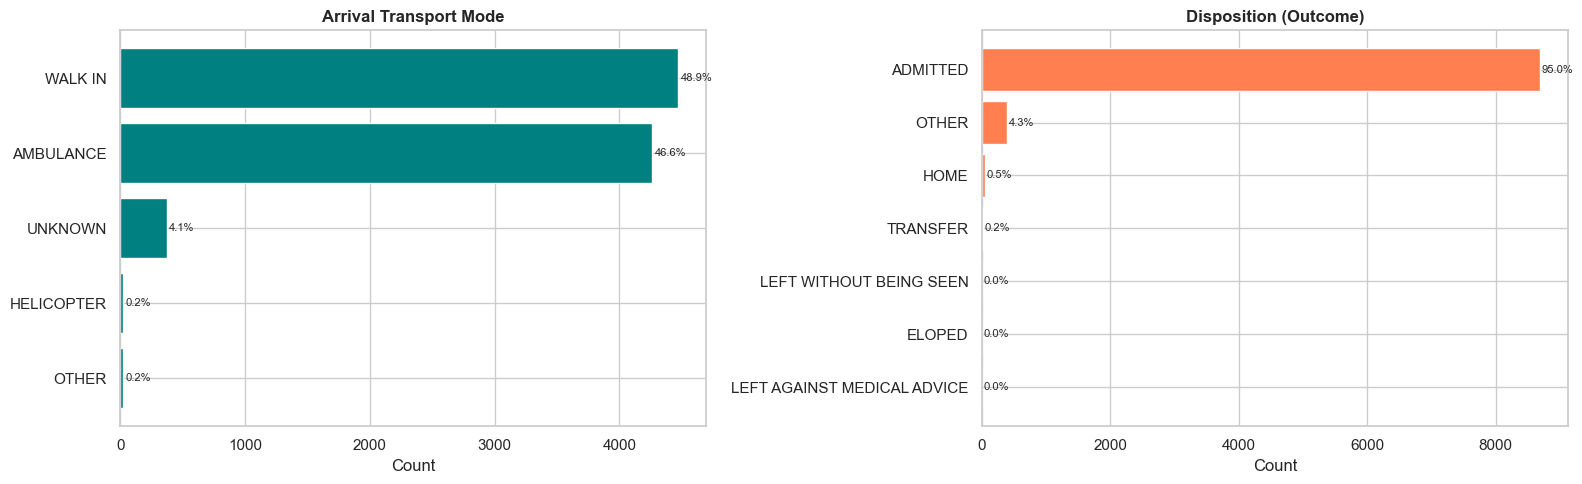

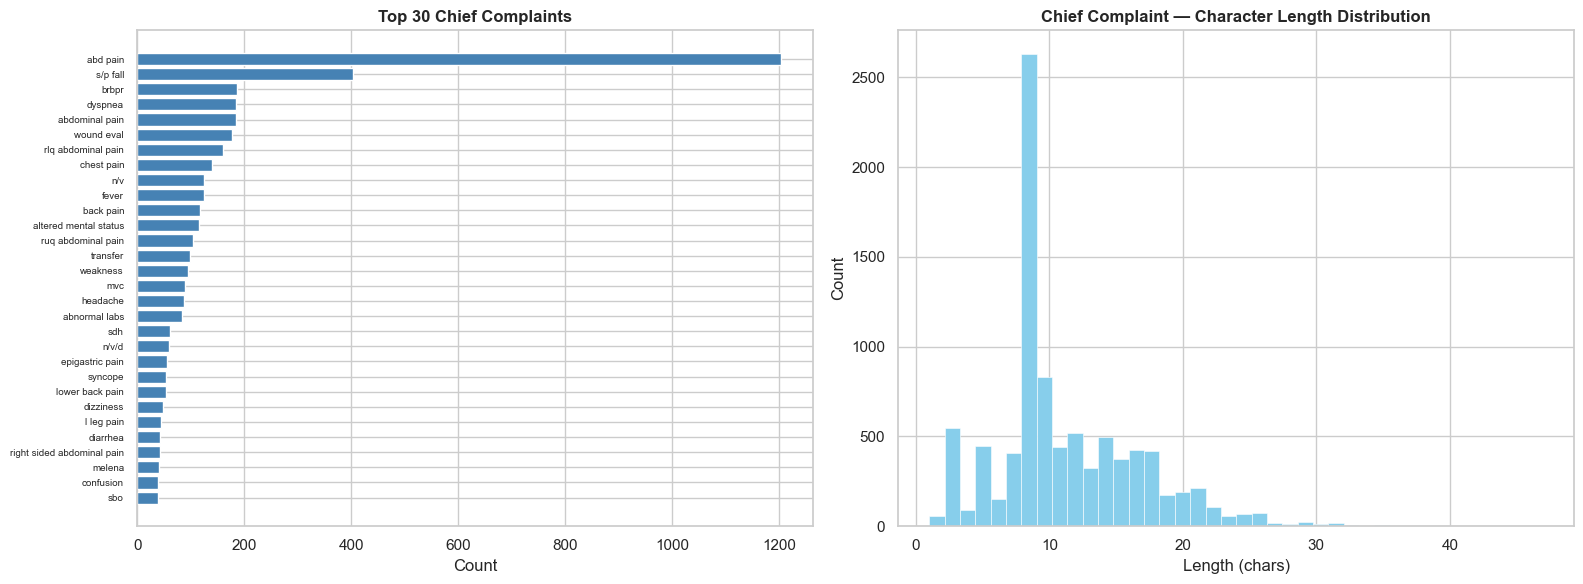

In [16]:
# ── 3.6  Categorical columns — chiefcomplaint, arrival_transport, disposition ─
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Arrival transport
transport = df_assess["arrival_transport"].value_counts(dropna=False)
axes[0].barh(transport.index.astype(str)[::-1], transport.values[::-1], color="teal")
for i, cnt in enumerate(transport.values[::-1]):
    pct = cnt / len(df_assess) * 100
    axes[0].text(cnt + 20, i, f"{pct:.1f}%", va="center", fontsize=8)
axes[0].set_title("Arrival Transport Mode", fontweight="bold")
axes[0].set_xlabel("Count")

# Disposition
disposition = df_assess["disposition"].value_counts(dropna=False)
axes[1].barh(disposition.index.astype(str)[::-1], disposition.values[::-1], color="coral")
for i, cnt in enumerate(disposition.values[::-1]):
    pct = cnt / len(df_assess) * 100
    axes[1].text(cnt + 20, i, f"{pct:.1f}%", va="center", fontsize=8)
axes[1].set_title("Disposition (Outcome)", fontweight="bold")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

# Chief complaint — top 30 + length distribution
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

top_cc = df_assess["chiefcomplaint"].str.lower().str.strip().value_counts().head(30)
axes2[0].barh(top_cc.index[::-1], top_cc.values[::-1], color="steelblue")
axes2[0].set_title("Top 30 Chief Complaints", fontweight="bold")
axes2[0].set_xlabel("Count")
axes2[0].tick_params(axis="y", labelsize=7)

cc_len = df_assess["chiefcomplaint"].dropna().str.len()
axes2[1].hist(cc_len, bins=40, color="skyblue", edgecolor="white", linewidth=0.4)
axes2[1].set_title("Chief Complaint — Character Length Distribution", fontweight="bold")
axes2[1].set_xlabel("Length (chars)")
axes2[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

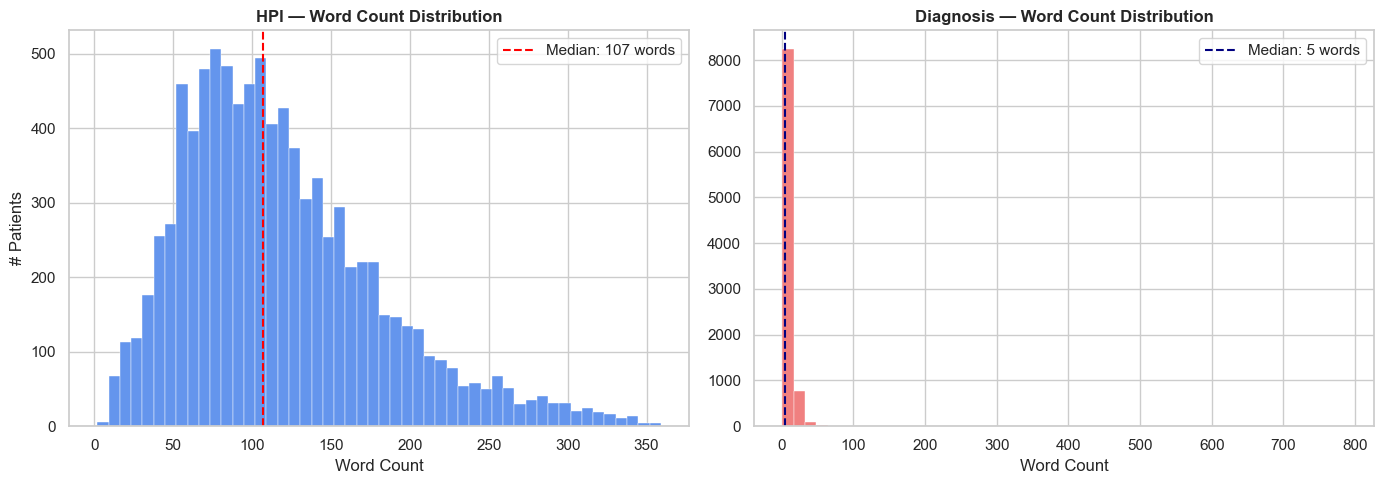

HPI — min: 0, median: 107, mean: 118, max: 359, zeros: 1
diagnosis — min: 0, median: 5, mean: 8, max: 787, zeros: 2


In [18]:
# ── 3.8  Text columns — HPI and diagnosis word-count distributions ────────────
def word_count(text):
    if not isinstance(text, str):
        return 0
    return len(text.split())

hpi_wc   = df_clinical["HPI"].apply(word_count)
diag_wc  = df_clinical["diagnosis"].apply(word_count)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hpi_wc[hpi_wc > 0], bins=50, color="cornflowerblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(hpi_wc.median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median: {hpi_wc.median():.0f} words")
axes[0].set_title("HPI — Word Count Distribution", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("# Patients")
axes[0].legend()

axes[1].hist(diag_wc[diag_wc > 0], bins=50, color="lightcoral", edgecolor="white", linewidth=0.3)
axes[1].axvline(diag_wc.median(), color="navy", linestyle="--", linewidth=1.5,
                label=f"Median: {diag_wc.median():.0f} words")
axes[1].set_title("Diagnosis — Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].legend()

plt.tight_layout()
plt.show()

for col, wc in [("HPI", hpi_wc), ("diagnosis", diag_wc)]:
    print(f"{col} — min: {wc.min()}, median: {wc.median():.0f}, mean: {wc.mean():.0f}, "
          f"max: {wc.max()}, zeros: {(wc == 0).sum()}")

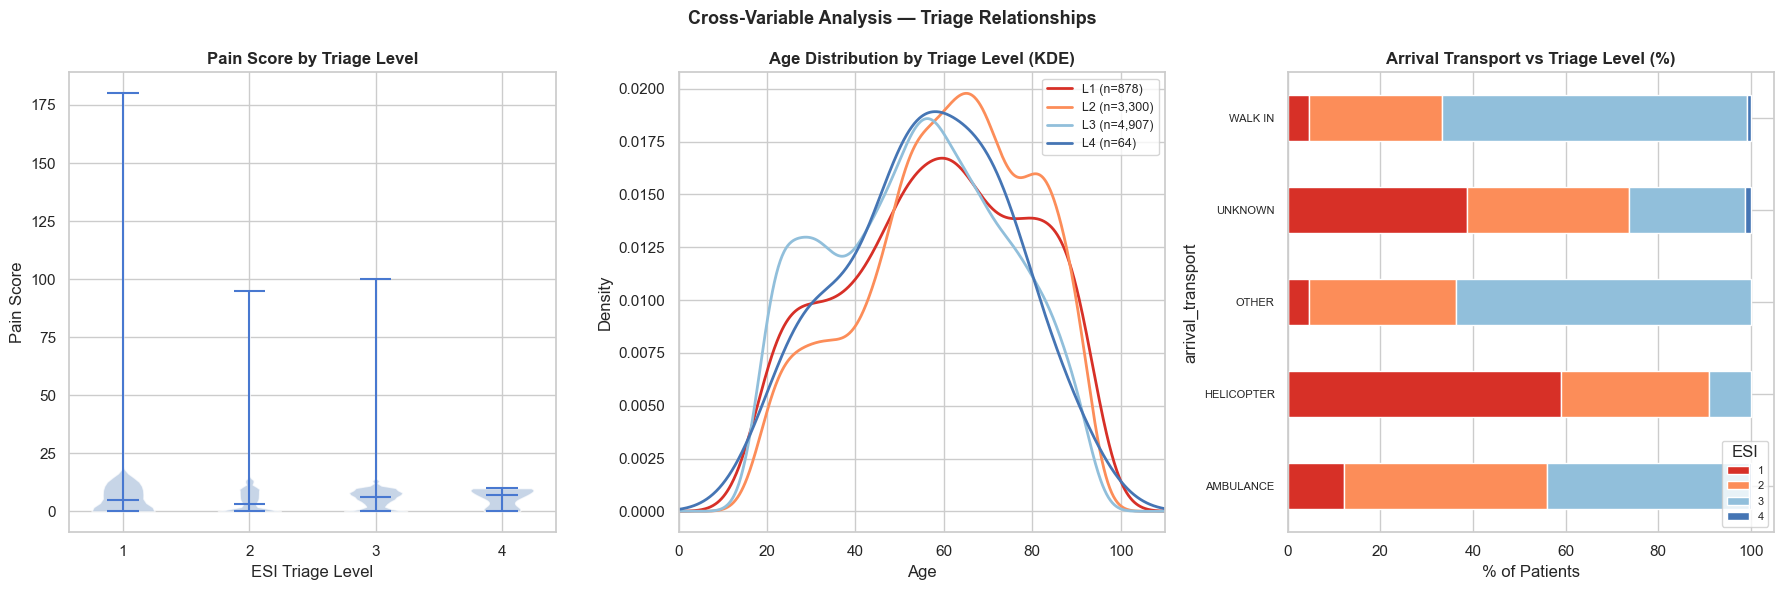

In [19]:
# ── 3.9  Cross-variable analysis — Triage vs Pain, Age, Arrival Transport ─────
import re

def parse_demographics_xv(text):
    """Local version of parse_demographics for self-contained cross-variable cell."""
    if not isinstance(text, str):
        return {"Gender": None, "Race": None, "Age": None}
    gender = re.search(r"Gender:\s*(\w+)", text, re.IGNORECASE)
    race   = re.search(r"Race:\s*([^,\n]+)", text, re.IGNORECASE)
    age    = re.search(r"Age:\s*(\d+)", text, re.IGNORECASE)
    return {
        "Gender": gender.group(1).strip().title() if gender else None,
        "Race":   race.group(1).strip().title() if race else None,
        "Age":    int(age.group(1)) if age else None,
    }

# Merge triage + parsed pain + parsed age for cross-analysis
df_cross = df_assess[["stay_id", "triage", "arrival_transport"]].copy()
df_cross["pain_numeric"] = pd.to_numeric(df_assess["pain"], errors="coerce")
df_cross = df_cross.merge(
    df_demo["stay_id"].to_frame().join(
        df_demo["patient_info"].apply(parse_demographics_xv).apply(pd.Series)
    ),
    on="stay_id", how="left"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_t = {1: "#d73027", 2: "#fc8d59", 3: "#91bfdb", 4: "#4575b4"}
triage_levels = sorted(df_cross["triage"].dropna().unique())

# --- Triage vs Pain (violin) ---
pain_by_triage = [df_cross.loc[df_cross["triage"] == t, "pain_numeric"].dropna().values
                  for t in triage_levels]
vp = axes[0].violinplot(pain_by_triage, positions=triage_levels, showmedians=True, showextrema=True)
for pc in vp["bodies"]:
    pc.set_facecolor("lightsteelblue")
    pc.set_alpha(0.7)
axes[0].set_title("Pain Score by Triage Level", fontweight="bold")
axes[0].set_xlabel("ESI Triage Level")
axes[0].set_ylabel("Pain Score")
axes[0].set_xticks(triage_levels)

# --- Age distribution by triage (KDE) ---
for t in triage_levels:
    subset = df_cross.loc[df_cross["triage"] == t, "Age"].dropna()
    if len(subset) > 10:
        subset.plot.kde(ax=axes[1], label=f"L{t} (n={len(subset):,})",
                        color=colors_t.get(t, "gray"), linewidth=2)
axes[1].set_title("Age Distribution by Triage Level (KDE)", fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 110)

# --- Triage vs Arrival Transport (stacked bar %) ---
ct = pd.crosstab(df_cross["arrival_transport"], df_cross["triage"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind="barh", stacked=True, ax=axes[2],
            color=[colors_t.get(t, "gray") for t in ct_pct.columns],
            legend=True)
axes[2].set_title("Arrival Transport vs Triage Level (%)", fontweight="bold")
axes[2].set_xlabel("% of Patients")
axes[2].legend(title="ESI", loc="lower right", fontsize=8)
axes[2].tick_params(axis="y", labelsize=8)

fig.suptitle("Cross-Variable Analysis — Triage Relationships", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 4 — Cleaning Decisions & Null Handling Strategy

Decisions are based on EDA results above and cross-validated against the dataset profile.
Only the 7 columns used as features for `triage` prediction are included.

### Null Handling

| Column | Null Count | % | Strategy |
|--------|-----------|---|----------|
| `chiefcomplaint` | 2 | <0.1% | Drop rows — too few to impute, required input |
| `HPI` | 1 | <0.1% | Drop row — too few to impute, required input |
| `past_medical_history` | ~30 | 0.3% | Fill with `""` — text model falls back to `"{chiefcomplaint}. {HPI}"` |
| `initial_vitals` (raw text) | 0 | 0% | No action on raw field. Individual parsed components (Temp/HR/etc.) may have gaps — see Cell 3.2 missing-rate chart; impute per-vital with **median stratified by triage level** if gap >1% |
| `pain` | ~260 | 2.8% | Numeric models: impute with median. Text/LLM models: use token `"pain: unknown"` |
| `patient_info` | 0 | 0% | No action |
| `arrival_transport` | 0 | 0% | No nulls, but see below |

### arrival_transport — Unknown/Other Handling

The bar chart (Cell 3.6) will show the proportion of `"UNKNOWN"`, `"OTHER"`, and similar low-signal categories.

| Scenario | Decision |
|----------|----------|
| Unknown/Other < 5% combined | Keep all categories as-is; encode normally |
| Unknown/Other 5–15% | Collapse into single `"OTHER"` bin; keep named categories |
| Unknown/Other > 15% | Evaluate dropping column from structured feature set; retain in text prompt only |

Cross-variable chart (Cell 3.9) shows arrival transport vs triage distribution — check whether Unknown/Other maps disproportionately to any triage level before deciding.

### Other Columns (not used as triage prediction features)

| Column | Decision |
|--------|----------|
| `diagnosis`, `primary_diagnosis`, `secondary_diagnosis` | Exclude — post-discharge labels, not available at triage time |
| `icd_code`, `icd_title`, `icd_version` | Exclude — post-discharge, DUA restriction |
| `disposition` | Exclude — outcome column, not available at triage time |
| `specialty` | Excluded from scope |
| `text` (full note) | Source for PMH extraction only; not a direct model input |


## Section 5 — Merge

Left join sequence anchored on `vital_signs.csv`.  
All joins use `stay_id` as the key. Duplicate columns get `_dup` suffix and are then dropped.

In [ ]:
def drop_dup_cols(df):
    """Drop any column whose name ends with '_dup' (artifact of suffixes=('','_dup'))."""
    dup_cols = [c for c in df.columns if c.endswith("_dup")]
    if dup_cols:
        print(f"  Dropping duplicate columns: {dup_cols}")
    return df.drop(columns=dup_cols)


# Step 1: Anchor — vital_signs (stay_id, subject_id, hadm_id, initial_vitals)
df = df_vitals.copy()
print(f"Step 1 — anchor (vital_signs):          shape = {df.shape}")

# Step 2: Left join clinical_data
# Contributes: text, HPI, tests, past_medication, diagnosis,
#              primary_diagnosis, secondary_diagnosis
df = df.merge(df_clinical, on="stay_id", how="left", suffixes=("", "_dup"))
df = drop_dup_cols(df)
print(f"Step 2 — after join clinical_data:      shape = {df.shape}")

# Step 3: Left join patient_demographics (contributes: patient_info)
df = df.merge(df_demo, on="stay_id", how="left", suffixes=("", "_dup"))
df = drop_dup_cols(df)
print(f"Step 3 — after join patient_demographics: shape = {df.shape}")

# Step 4: Left join initial_assessment_info
# Contributes: triage, pain, chiefcomplaint, arrival_transport, disposition,
#              icd_code, icd_title, icd_version
df = df.merge(df_assess, on="stay_id", how="left", suffixes=("", "_dup"))
df = drop_dup_cols(df)
print(f"Step 4 — after join initial_assessment_info: shape = {df.shape}")

# Step 5: Left join specialty_referral — keep only stay_id + specialty
# ~6,949 rows will be NaN for specialty — expected behaviour
df_spec_slim = df_specialty[["stay_id", "specialty"]].copy()
df = df.merge(df_spec_slim, on="stay_id", how="left", suffixes=("", "_dup"))
df = drop_dup_cols(df)
print(f"Step 5 — after join specialty_referral: shape = {df.shape}")
print(f"\n  specialty NaN count (expected ~6,949): {df['specialty'].isna().sum()}")

# Final shape check before adding past_medical_history
assert df.shape == (9149, 21), (
    f"Expected (9149, 21) after merge, got {df.shape}. "
    "Check for fan-out caused by duplicate stay_ids in a source file."
)
print(f"\nMerge complete. Shape confirmed: {df.shape}")
print(f"Columns: {list(df.columns)}")

## Section 6 — Extract `past_medical_history`

The `text` column (from `clinical_data.csv`) contains a full discharge-style clinical note.  
We extract the section between `"Past Medical History:"` and the next section header using a regex.

In [ ]:
def extract_pmh(text):
    """
    Extract the 'Past Medical History' section from a clinical note.

    Looks for 'Past Medical History:' and captures everything up to the
    next section header (a capitalised line ending in ':') or end of string.
    Returns None if the text is not a string or the section is not found.
    """
    if not isinstance(text, str):
        return None
    match = re.search(
        r"Past Medical History:\s*(.*?)(?=\n[A-Z][^\n]+:|$)",
        text,
        re.DOTALL,
    )
    return match.group(1).strip() if match else None


# Apply extraction — operates on the 'text' column inherited from clinical_data
df["past_medical_history"] = df["text"].apply(extract_pmh)

null_count = df["past_medical_history"].isna().sum()
print(f"past_medical_history null count: {null_count}  (expected ~30)")

# Spot-check a few extracted values to confirm extraction quality
print("\nSample extracted PMH values (first 3 non-null):")
samples = df["past_medical_history"].dropna().head(3)
for i, val in enumerate(samples, 1):
    preview = val[:200].replace("\n", " ")
    print(f"  [{i}] {repr(preview)}")

### Section 6b — EDA: `past_medical_history`

Analyse the extracted PMH column before it enters the final schema. Checks: null count, word count distribution, string-encoded nulls, and sample values.

In [ ]:
# ── 6b  past_medical_history — EDA after extraction ─────────────────────────
# NOTE: Run Section 5 (merge) + Section 6 (extract) before this cell.

pmh = df["past_medical_history"]

# --- Null / empty analysis ---
null_count  = pmh.isna().sum()
empty_count = (pmh.fillna("").str.strip() == "").sum()
fake_nulls  = pmh.astype(str).str.strip().str.lower().isin(["nan", "none", "null"])

print(f"Total rows          : {len(pmh):,}")
print(f"True NaN            : {null_count}  ({null_count/len(pmh)*100:.1f}%)")
print(f"Empty string ('')   : {empty_count - null_count}")
print(f"String-encoded nulls: {fake_nulls.sum()}")
print(f"Non-null, non-empty : {(~pmh.isna() & (pmh.str.strip() != '')).sum():,}")

# --- Word count distribution ---
pmh_wc = pmh.dropna().apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pmh_wc[pmh_wc > 0], bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(pmh_wc.median(), color="red",  linestyle="--", linewidth=1.5,
                label=f"Median: {pmh_wc.median():.0f} words")
axes[0].axvline(pmh_wc.mean(),   color="navy", linestyle="--", linewidth=1.5,
                label=f"Mean: {pmh_wc.mean():.0f} words")
axes[0].set_title("past_medical_history — Word Count Distribution", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("# Patients")
axes[0].legend()

# Short PMH entries (≤5 words) — likely low-content: "None", "Denies", "N/A", etc.
short_pmh = pmh.dropna()[pmh_wc <= 5]
short_counts = short_pmh.str.strip().str.lower().value_counts().head(20)
axes[1].barh(short_counts.index[::-1], short_counts.values[::-1], color="salmon")
axes[1].set_title("PMH entries ≤ 5 words (top 20)\n— likely low-information", fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

print(f"\nWord count stats — min: {pmh_wc.min()}, median: {pmh_wc.median():.0f}, "
      f"mean: {pmh_wc.mean():.0f}, max: {pmh_wc.max()}")
print(f"Entries ≤ 5 words   : {(pmh_wc <= 5).sum()} ({(pmh_wc <= 5).mean()*100:.1f}%)")

# --- Sample values ---
print("\n── Sample PMH values (non-null, >5 words) ──")
samples = pmh.dropna()[pmh_wc > 5].head(5)
for i, val in enumerate(samples, 1):
    print(f"  [{i}] {str(val)[:200].replace(chr(10), ' ')}")


## Section 7 — Reorder Columns & Validate

Reorder to the canonical 22-column schema, then assert shape, column order, and stay_id uniqueness.

In [ ]:
# Target column order — matches consolidated_dataset_PMH.csv schema exactly
TARGET_COLUMNS = [
    "stay_id",
    "subject_id",
    "hadm_id",
    "text",
    "HPI",
    "patient_info",
    "initial_vitals",
    "tests",
    "past_medication",
    "diagnosis",
    "primary_diagnosis",
    "secondary_diagnosis",
    "triage",
    "pain",
    "chiefcomplaint",
    "arrival_transport",
    "disposition",
    "icd_code",
    "icd_title",
    "icd_version",
    "specialty",
    "past_medical_history",
]

# Confirm all target columns exist in df before reordering
missing_cols = [c for c in TARGET_COLUMNS if c not in df.columns]
extra_cols   = [c for c in df.columns if c not in TARGET_COLUMNS]
if missing_cols:
    print(f"WARNING — columns in target schema but missing from df: {missing_cols}")
if extra_cols:
    print(f"INFO — extra columns in df not in target schema (will be dropped): {extra_cols}")

# Reorder (also implicitly drops any extra columns not in TARGET_COLUMNS)
df = df[TARGET_COLUMNS]

# --- Assertions ---
assert df.shape == (9149, 22), (
    f"Shape assertion failed: expected (9149, 22), got {df.shape}"
)
assert list(df.columns) == TARGET_COLUMNS, (
    f"Column order mismatch.\nExpected: {TARGET_COLUMNS}\nGot: {list(df.columns)}"
)
assert df["stay_id"].nunique() == 9149, (
    f"stay_id uniqueness failed: {df['stay_id'].nunique()} unique values (expected 9149)"
)

print(f"Validation passed. Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

## Section 8 — Save

Save the final dataframe to `Data Preparation/consolidated_dataset_PMH_v2.csv`.  
The path is relative to this notebook's location (`../` goes up one level from `Data Preparation/` to the project root, then back into `Data Preparation/`).

In [ ]:
# Output path is relative to this notebook (which lives in Data Preparation/).
# Using a relative path keeps the project portable across machines.
OUTPUT_PATH = "../Data Preparation/consolidated_dataset_PMH_v2.csv"

# index=False — stay_id is already a column; we do not want an extra integer index column.
df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Shape: {df.shape}  ({df.shape[0]} rows x {df.shape[1]} columns)")